# TUGAS 2 - IMPLEMENTASI PENALARAN
## Sistem Fuzzy Penentuan Gaji Pegawai Baru (Metode Tsukamoto)

**Bagian A - Program Kelompok**


### 1. Menampilkan Universe Setiap Variabel


In [ ]:
print("Universe Variabel:")
print("1. Pengalaman kerja (Input):")
print("   - Rentang: 0 - 25")
print("   - Satuan: tahun")
print("   - Ketelitian: bebas")
print("   - Jumlah linguistik: 2 (Sedikit, Banyak)")
print("\n2. Nilai ujian (Input):")
print("   - Rentang: 0 - 10")
print("   - Satuan: -")
print("   - Ketelitian: 0.1")
print("   - Jumlah linguistik: 3 (Rendah, Sedang, Tinggi)")
print("\n3. Gaji (Output):")
print("   - Rentang: Rp1.000.000 - Rp20.000.000")
print("   - Satuan: Rupiah (Rp)")
print("   - Ketelitian: bebas")
print("   - Jumlah linguistik: 2 (Kecil, Besar)")


Universe Variabel:
1. Pengalaman kerja (Input):
   - Rentang: 0 - 25
   - Satuan: tahun
   - Ketelitian: bebas
   - Jumlah linguistik: 2 (Sedikit, Banyak)

2. Nilai ujian (Input):
   - Rentang: 0 - 10
   - Satuan: -
   - Ketelitian: 0.1
   - Jumlah linguistik: 3 (Rendah, Sedang, Tinggi)

3. Gaji (Output):
   - Rentang: Rp1.000.000 - Rp20.000.000
   - Satuan: Rupiah (Rp)
   - Ketelitian: bebas
   - Jumlah linguistik: 2 (Kecil, Besar)


### 2. Mendefinisikan Fungsi Keanggotaan
Membuat fungsi-fungsi untuk menghitung nilai keanggotaan (fuzzifikasi) untuk setiap himpunan fuzzy pada masing-masing variabel.


In [ ]:
import matplotlib.pyplot as plt

# Fungsi keanggotaan Pengalaman Kerja
def mu_pengalaman_sedikit(x):
    if x <= 5: return 1.0
    elif 5 < x < 15: return (15 - x) / (15 - 5)
    else: return 0.0

def mu_pengalaman_banyak(x):
    if x <= 10: return 0.0
    elif 10 < x < 20: return (x - 10) / (20 - 10)
    else: return 1.0

# Fungsi keanggotaan Nilai Ujian
def mu_ujian_rendah(x):
    if x <= 0: return 1.0
    elif 0 < x < 5: return (5 - x) / (5 - 0)
    else: return 0.0

def mu_ujian_sedang(x):
    if x <= 2 or x >= 8: return 0.0
    elif 2 < x < 4: return (x - 2) / (4 - 2)
    elif 4 <= x <= 6: return 1.0
    elif 6 < x < 8: return (8 - x) / (8 - 6)

def mu_ujian_tinggi(x):
    if x <= 5: return 0.0
    elif 5 < x < 10: return (x - 5) / (10 - 5)
    else: return 1.0

# Fungsi keanggotaan Gaji
def mu_gaji_kecil(z):
    if z <= 1000000: return 1.0
    elif 1000000 < z < 20000000: return (20000000 - z) / (20000000 - 1000000)
    else: return 0.0

def mu_gaji_besar(z):
    if z <= 1000000: return 0.0
    elif 1000000 < z < 20000000: return (z - 1000000) / (20000000 - 1000000)
    else: return 1.0

# Invers fungsi keanggotaan Gaji (untuk defuzzifikasi)
def invers_gaji_kecil(alpha):
    return 20000000 - alpha * (20000000 - 1000000)

def invers_gaji_besar(alpha):
    return 1000000 + alpha * (20000000 - 1000000)


### 3. Menggambar Grafik Fungsi Keanggotaan


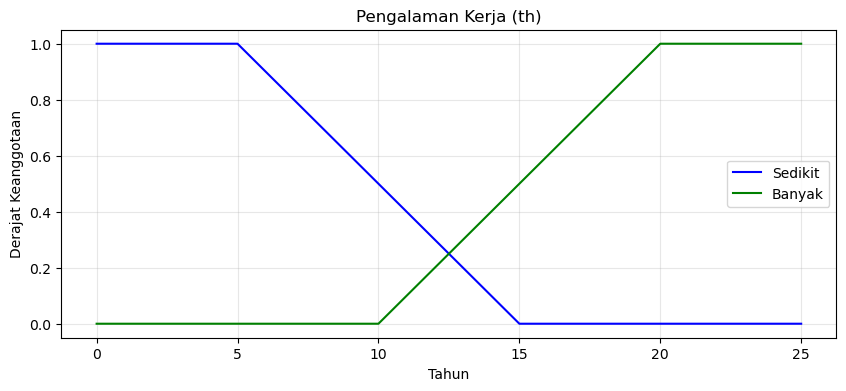

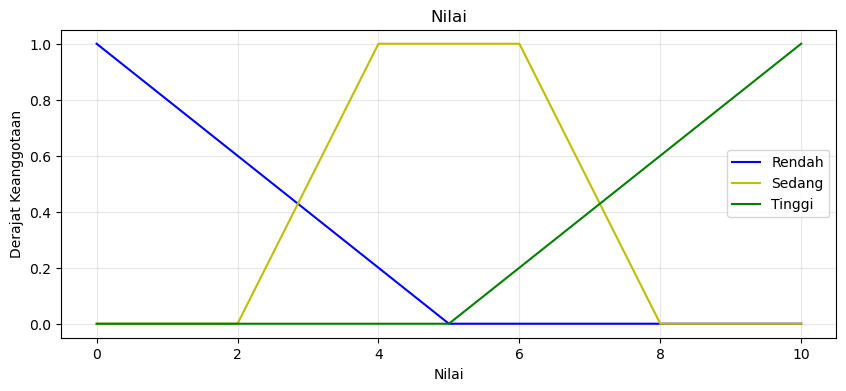

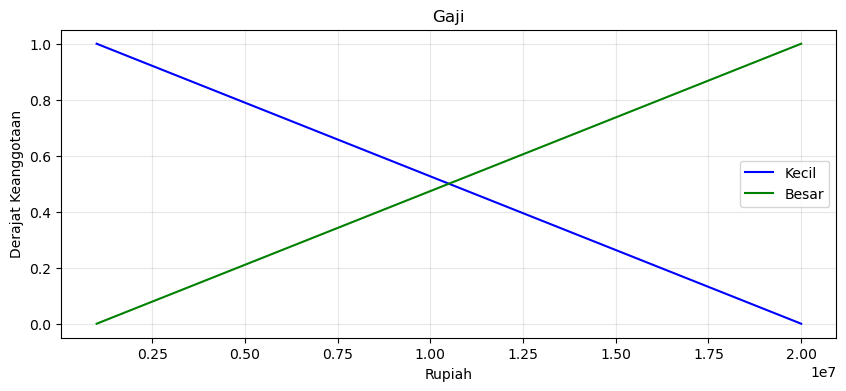

In [ ]:
# Generate data points untuk plot
x_pengalaman = [i/10 for i in range(0, 251)]
y_pengalaman_sedikit = [mu_pengalaman_sedikit(x) for x in x_pengalaman]
y_pengalaman_banyak = [mu_pengalaman_banyak(x) for x in x_pengalaman]

x_ujian = [i/10 for i in range(0, 101)]
y_ujian_rendah = [mu_ujian_rendah(x) for x in x_ujian]
y_ujian_sedang = [mu_ujian_sedang(x) for x in x_ujian]
y_ujian_tinggi = [mu_ujian_tinggi(x) for x in x_ujian]

x_gaji = [i for i in range(1000000, 20000001, 100000)]
y_gaji_kecil = [mu_gaji_kecil(x) for x in x_gaji]
y_gaji_besar = [mu_gaji_besar(x) for x in x_gaji]

# Plot Pengalaman Kerja
plt.figure(figsize=(10, 4))
plt.plot(x_pengalaman, y_pengalaman_sedikit, label='Sedikit', color='blue')
plt.plot(x_pengalaman, y_pengalaman_banyak, label='Banyak', color='green')
plt.title('Pengalaman Kerja (th)')
plt.xlabel('Tahun')
plt.ylabel('Derajat Keanggotaan')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot Nilai Ujian
plt.figure(figsize=(10, 4))
plt.plot(x_ujian, y_ujian_rendah, label='Rendah', color='blue')
plt.plot(x_ujian, y_ujian_sedang, label='Sedang', color='y')
plt.plot(x_ujian, y_ujian_tinggi, label='Tinggi', color='green')
plt.title('Nilai')
plt.xlabel('Nilai')
plt.ylabel('Derajat Keanggotaan')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot Gaji
plt.figure(figsize=(10, 4))
plt.plot(x_gaji, y_gaji_kecil, label='Kecil', color='blue')
plt.plot(x_gaji, y_gaji_besar, label='Besar', color='green')
plt.title('Gaji')
plt.xlabel('Rupiah')
plt.ylabel('Derajat Keanggotaan')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 4 & 5. Meminta dan Memvalidasi Input Pengguna
Menerima input dengan validasi rentang dan ketelitian.


In [ ]:
def get_pengalaman():
    while True:
        try:
            inp = input("Masukkan Pengalaman Kerja (0-25 tahun): ")
            if not inp.strip():
                print("Input tidak boleh kosong. Silakan coba lagi.")
                continue
            val = float(inp)
            if 0 <= val <= 25:
                return val
            else:
                print("Peringatan: Pengalaman kerja harus berada dalam rentang 0 - 25 tahun.")
        except ValueError:
            print("Input harus berupa angka.")

def get_nilai_ujian():
    while True:
        try:
            inp = input("Masukkan Nilai Ujian (0-10, ketelitian 0.1): ")
            if not inp.strip():
                print("Input tidak boleh kosong. Silakan coba lagi.")
                continue
            val = float(inp)
            if 0 <= val <= 10:
                # Cek ketelitian 0.1
                rounded_val = round(val, 1)
                if abs(val - rounded_val) > 1e-9:
                    print(f"Peringatan: Ketelitian nilai ujian adalah 0.1. Nilai {val} dibulatkan menjadi {rounded_val}.")
                return rounded_val
            else:
                print("Peringatan: Nilai ujian harus berada dalam rentang 0 - 10.")
        except ValueError:
            print("Input harus berupa angka.")

pengalaman_input = get_pengalaman()
ujian_input = get_nilai_ujian()

print(f"\nInput diterima: Pengalaman = {pengalaman_input} tahun, Nilai Ujian = {ujian_input}")



Input diterima: Pengalaman = 20.0 tahun, Nilai Ujian = 7.0


### 6. Menampilkan Derajat Keanggotaan Input


In [ ]:
mu_peng_sedikit = mu_pengalaman_sedikit(pengalaman_input)
mu_peng_banyak = mu_pengalaman_banyak(pengalaman_input)

mu_uj_rendah = mu_ujian_rendah(ujian_input)
mu_uj_sedang = mu_ujian_sedang(ujian_input)
mu_uj_tinggi = mu_ujian_tinggi(ujian_input)

print("Derajat Keanggotaan Pengalaman Kerja:")
print(f"- Sedikit: {mu_peng_sedikit:.4f}")
print(f"- Banyak: {mu_peng_banyak:.4f}")

print("\nDerajat Keanggotaan Nilai Ujian:")
print(f"- Rendah: {mu_uj_rendah:.4f}")
print(f"- Sedang: {mu_uj_sedang:.4f}")
print(f"- Tinggi: {mu_uj_tinggi:.4f}")


Derajat Keanggotaan Pengalaman Kerja:
- Sedikit: 0.0000
- Banyak: 1.0000

Derajat Keanggotaan Nilai Ujian:
- Rendah: 0.0000
- Sedang: 0.5000
- Tinggi: 0.4000


## A. Fungsi Keanggotan Nilai Ujian Sedang

**NIM:** 2415354014

**Nama:** I Gede Adithya Bimantara

### Perhitungan Manual Fuzzifikasi: Fungsi Keanggotaan Nilai Ujian "Sedang"

Parameter trapesium: $a=2,\ b=4,\ c=6,\ d=8$

$$
\mu_{Sedang}(x)=
\begin{cases}
0, & x \le 2 \text{ atau } x \ge 8\\
\dfrac{x-2}{4-2}, & 2 < x < 4\\
1, & 4 \le x \le 6\\
\dfrac{8-x}{8-6}, & 6 < x < 8
\end{cases}
$$

Input: $x = 7{,}0$

Karena $6 < 7{,}0 < 8$, maka dipakai segmen turun:

$$
\mu_{Sedang}(7{,}0)=\frac{8-7{,}0}{8-6}=\frac{1}{2}=0{,}5
$$

**Hasil:** $\mu_{Sedang}(7{,}0)=0{,}5$

Perbandingan dengan output program (sel 10): `- Sedang: 0.5000` 


## B. Fungsi Keanggotan Nilai Ujian Rendah

**NIM:** 2415354078

**Nama:** I Gusti Ngurah Agung Kesawa Paramahamsa

### Perhitungan Manual Fuzzifikasi: Fungsi Keanggotaan Nilai Ujian "Rendah"

Parameter bahu kiri (turun linear): $a = 0, b = 5$

$$\mu_{Rendah}(x) = \begin{cases} 1, & x \le 0 \\ \frac{5 - x}{5 - 0}, & 0 < x < 5 \\ 0, & x \ge 5 \end{cases}$$

Input: $x = 7,0$

Karena $7,0 \ge 5$, maka dipakai segmen bernilai nol:

$$\mu_{Rendah}(7,0) = 0$$

**Hasil: $\mu_{Rendah}(7,0) = 0$**

Perbandingan dengan output program (sel 10): `- Rendah: 0.0000`

## C. Fungsi Keanggotan Nilai Ujian Tinggi

**NIM:** 2415354058

**Nama:** I Made Santika Kumara Ananda

### Perhitungan Manual Fuzzifikasi: Fungsi Keanggotaan Nilai Ujian "Tinggi"

Parameter bahu kanan (naik linear): $a=5,\ b=10$

$$
\mu_{Tinggi}(x)=
\begin{cases}
0, & x \le 5\\
\dfrac{x-5}{10-5}, & 5 < x < 10\\
1, & x \ge 10
\end{cases}
$$

Input: $x = 7{,}0$

Karena $5 < 7{,}0 < 10$, maka dipakai segmen naik:

$$
\mu_{Tinggi}(7{,}0)=\frac{7{,}0-5}{10-5}=\frac{2}{5}=0{,}4
$$

**Hasil:** $\mu_{Tinggi}(7{,}0)=0{,}4$

Perbandingan dengan output program (sel 10): `- Tinggi: 0.4000` 



### 7. Inferensi Tsukamoto (Alpha dan Z setiap Rule)
Menghitung $\alpha$-predikat (dengan operator min) dan nilai $z$ hasil inversi dari fungsi keanggotaan output.


In [ ]:
# Rule 1: JIKA Pengalaman Sedikit DAN Nilai Rendah MAKA Gaji Kecil
alpha1 = min(mu_peng_sedikit, mu_uj_rendah)
z1 = invers_gaji_kecil(alpha1)
print(f"Rule 1 (Sedikit AND Rendah -> Kecil): α = {alpha1:.4f}, z = Rp {z1:,.2f}")

# Rule 2: JIKA Pengalaman Sedikit DAN Nilai Sedang MAKA Gaji Kecil
alpha2 = min(mu_peng_sedikit, mu_uj_sedang)
z2 = invers_gaji_kecil(alpha2)
print(f"Rule 2 (Sedikit AND Sedang -> Kecil): α = {alpha2:.4f}, z = Rp {z2:,.2f}")

# Rule 3: JIKA Pengalaman Sedikit DAN Nilai Tinggi MAKA Gaji Kecil
alpha3 = min(mu_peng_sedikit, mu_uj_tinggi)
z3 = invers_gaji_kecil(alpha3)
print(f"Rule 3 (Sedikit AND Tinggi -> Kecil): α = {alpha3:.4f}, z = Rp {z3:,.2f}")

# Rule 4: JIKA Pengalaman Banyak DAN Nilai Rendah MAKA Gaji Kecil
alpha4 = min(mu_peng_banyak, mu_uj_rendah)
z4 = invers_gaji_kecil(alpha4)
print(f"Rule 4 (Banyak AND Rendah  -> Kecil): α = {alpha4:.4f}, z = Rp {z4:,.2f}")

# Rule 5: JIKA Pengalaman Banyak DAN Nilai Sedang MAKA Gaji Besar
alpha5 = min(mu_peng_banyak, mu_uj_sedang)
z5 = invers_gaji_besar(alpha5)
print(f"Rule 5 (Banyak AND Sedang  -> Besar): α = {alpha5:.4f}, z = Rp {z5:,.2f}")

# Rule 6: JIKA Pengalaman Banyak DAN Nilai Tinggi MAKA Gaji Besar
alpha6 = min(mu_peng_banyak, mu_uj_tinggi)
z6 = invers_gaji_besar(alpha6)
print(f"Rule 6 (Banyak AND Tinggi  -> Besar): α = {alpha6:.4f}, z = Rp {z6:,.2f}")


Rule 1 (Sedikit AND Rendah -> Kecil): α = 0.0000, z = Rp 20,000,000.00
Rule 2 (Sedikit AND Sedang -> Kecil): α = 0.0000, z = Rp 20,000,000.00
Rule 3 (Sedikit AND Tinggi -> Kecil): α = 0.0000, z = Rp 20,000,000.00
Rule 4 (Banyak AND Rendah  -> Kecil): α = 0.0000, z = Rp 20,000,000.00
Rule 5 (Banyak AND Sedang  -> Besar): α = 0.5000, z = Rp 10,500,000.00
Rule 6 (Banyak AND Tinggi  -> Besar): α = 0.4000, z = Rp 8,600,000.00


## B. Rule 6

**NIM:** 2415354014

**Nama:** I Gede Adithya Bimantara

### Perhitungan Manual α dan z: Rule 6

**Rule 6:** JIKA Pengalaman **Banyak** DAN Nilai Ujian **Tinggi** MAKA Gaji **Besar**

**Langkah 1 – Derajat keanggotaan input**

Pengalaman Banyak, parameter $10 \to 20$:

$$
\mu_{Banyak}(x)=
\begin{cases}
0, & x \le 10\\
\dfrac{x-10}{20-10}, & 10<x<20\\
1, & x \ge 20
\end{cases}
\Rightarrow \mu_{Banyak}(20)=1 \quad (x \ge 20)
$$

Nilai Tinggi, parameter $5 \to 10$:

$$
\mu_{Tinggi}(7{,}0)=\frac{7{,}0-5}{10-5}=\frac{2}{5}=0{,}4
$$

**Langkah 2 – α-predikat (operator AND = min)**

$$
\alpha_6=\min(\mu_{Banyak}(20),\ \mu_{Tinggi}(7{,}0))=\min(1;\ 0{,}4)=0{,}4
$$

**Langkah 3 – Inversi fungsi keanggotaan Gaji "Besar" (kurva naik)**

$$
\mu_{Besar}(z)=\frac{z-1.000.000}{20.000.000-1.000.000}=\alpha
$$

$$
z = 1.000.000 + \alpha\,(20.000.000-1.000.000) = 1.000.000 + 19.000.000\,\alpha
$$

**Langkah 4 – Substitusi**

$$
z_6 = 1.000.000 + 19.000.000 \times 0{,}4 = 1.000.000 + 7.600.000 = 8.600.000
$$

**Hasil:** $\alpha_6 = 0{,}4$ dan $z_6 = \text{Rp}\,8.600.000$





## C. Rule 1

**NIM:** 2415354078

**Nama:** I Gusti Ngurah Agung Kesawa Paramahamsa

### Perhitungan Manual $\alpha$ dan $z$: Rule 1

**Rule 1:** JIKA Pengalaman **Sedikit** DAN Nilai Ujian **Rendah** MAKA Gaji **Kecil**

#### Langkah 1 – Derajat keanggotaan input

Pengalaman Sedikit, parameter $5 \rightarrow 15$:

$$\mu_{Sedikit}(x) = \begin{cases} 1, & x \le 5 \\ \frac{15 - x}{15 - 5}, & 5 < x < 15 \implies \mu_{Sedikit}(20) = 0 \quad (x \ge 15) \\ 0, & x \ge 15 \end{cases}$$

Nilai Rendah, parameter $0 \rightarrow 5$:

$$\mu_{Rendah}(7,0) = 0 \quad (x \ge 5)$$

#### Langkah 2 – $\alpha$-predikat (operator AND = min)

$$\alpha_1 = \min(\mu_{Sedikit}(20), \mu_{Rendah}(7,0)) = \min(0; 0) = 0$$

#### Langkah 3 – Inversi fungsi keanggotaan Gaji "Kecil" (kurva turun)

$$\mu_{Kecil}(z) = \frac{20.000.000 - z}{20.000.000 - 1.000.000} = \alpha$$

$$z = 20.000.000 - \alpha (20.000.000 - 1.000.000) = 20.000.000 - 19.000.000 \alpha$$

#### Langkah 4 – Substitusi

$$z_1 = 20.000.000 - 19.000.000 \times 0 = 20.000.000$$

**Hasil: $\alpha_1 = 0$ dan $z_1 = \text{Rp 20.000.000}$**

## D. Rule 5

**NIM:** 2415354058

**Nama:** I Made Santika Kumara Ananda

### Perhitungan Manual α dan z: Rule 5

**Rule 5:** JIKA Pengalaman **Banyak** DAN Nilai Ujian **Sedang** MAKA Gaji **Besar**

**Langkah 1 – Derajat keanggotaan input**

Pengalaman Banyak, parameter $10 \to 20$:

$$
\mu_{Banyak}(x)=
\begin{cases}
0, & x \le 10\\
\dfrac{x-10}{20-10}, & 10<x<20\\
1, & x \ge 20
\end{cases}
\Rightarrow \mu_{Banyak}(20)=1 \quad (x \ge 20)
$$

Nilai Sedang, parameter trapesium $2, 4, 6, 8$:

$$
\mu_{Sedang}(7{,}0)=\frac{8-7{,}0}{8-6}=\frac{1}{2}=0{,}5
$$

**Langkah 2 – α-predikat (operator AND = min)**

$$
\alpha_5=\min(\mu_{Banyak}(20),\ \mu_{Sedang}(7{,}0))=\min(1;\ 0{,}5)=0{,}5
$$

**Langkah 3 – Inversi fungsi keanggotaan Gaji "Besar" (kurva naik)**

$$
\mu_{Besar}(z)=\frac{z-1.000.000}{20.000.000-1.000.000}=\alpha
$$

$$
z = 1.000.000 + \alpha\,(20.000.000-1.000.000) = 1.000.000 + 19.000.000\,\alpha
$$

**Langkah 4 – Substitusi**

$$
z_5 = 1.000.000 + 19.000.000 \times 0{,}5 = 1.000.000 + 9.500.000 = 10.500.000
$$

**Hasil:** $\alpha_5 = 0{,}5$ dan $z_5 = \text{Rp}\,10.500.000$



### 8. Defuzzifikasi dan Gaji Akhir


In [ ]:
# Defuzzifikasi Tsukamoto (Rata-rata berbobot)
total_alpha_z = (alpha1*z1) + (alpha2*z2) + (alpha3*z3) + (alpha4*z4) + (alpha5*z5) + (alpha6*z6)
total_alpha = alpha1 + alpha2 + alpha3 + alpha4 + alpha5 + alpha6

if total_alpha > 0:
    gaji_akhir = total_alpha_z / total_alpha
else:
    gaji_akhir = 0

print(f"\nGaji Akhir Pegawai Baru: Rp {gaji_akhir:,.2f}")



Gaji Akhir Pegawai Baru: Rp 9,655,555.56
